In [55]:
import numpy as np
from numpy.linalg import inv
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures

In [56]:
#Demo Code 1: Binary Classification
X = np.array([[-9],[-7],[-5],[1],[5],[9]])
y = np.array([[-1],[-1],[-1],[1],[1],[1]])

X = np.c_[np.ones((X.shape[0],1)),X]
w = inv(X.T @ X) @ X.T @ y #Overdetermined system
print(w)

X_test = np.array([-2])
X_test = np.c_[np.ones((X_test.shape[0],1)),X_test]

y_predict = np.sign(X_test @ w)
print("Predicted class:", y_predict)


[[0.140625]
 [0.140625]]
Predicted class: [[-1.]]


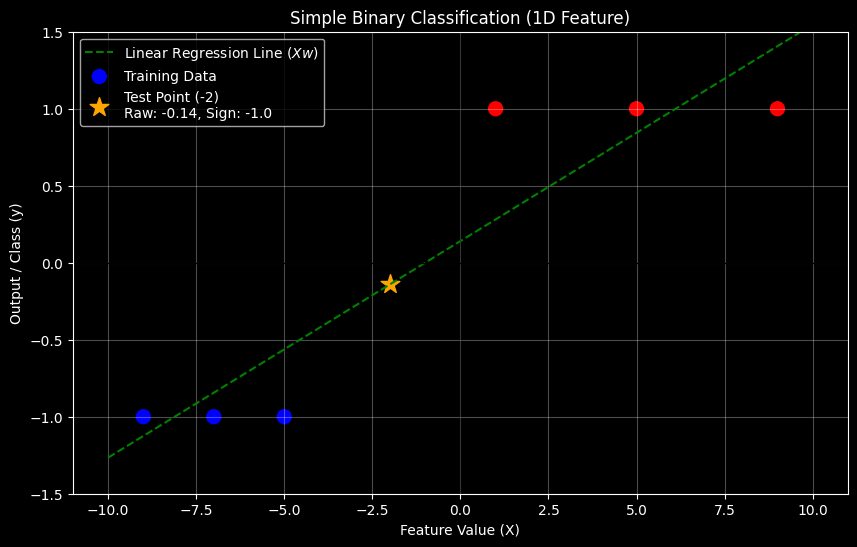

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data
X_raw = np.array([[-9],[-7],[-5],[1],[5],[9]])
y = np.array([[-1],[-1],[-1],[1],[1],[1]])

# 2. Solve for w
X = np.c_[np.ones((X_raw.shape[0],1)), X_raw]
w = np.linalg.inv(X.T @ X) @ X.T @ y

# 3. Create line for the model
x_line = np.linspace(-10, 10, 100)
# We add the 1s for the bias term to calculate the line
y_line = w[0] + w[1] * x_line

# 4. Prediction for X_test = -2
x_test_val = -2
y_test_raw = w[0] + w[1] * x_test_val
y_test_pred = np.sign(y_test_raw)

# 5. Plotting
plt.figure(figsize=(10, 6))

# Plot the regression line
plt.plot(x_line, y_line, 'g--', label='Linear Regression Line ($Xw$)')
plt.axhline(0, color='black', linewidth=1) # The decision threshold
plt.axvline(0, color='black', linewidth=1, alpha=0.3)

# Plot the training data
plt.scatter(X_raw, y, c=['blue' if val == -1 else 'red' for val in y], s=100, label='Training Data')

# Highlight the Test Point
plt.scatter(x_test_val, y_test_raw, color='orange', marker='*', s=200,
            label=f'Test Point (-2)\nRaw: {y_test_raw[0]:.2f}, Sign: {y_test_pred[0]}')

plt.title("Simple Binary Classification (1D Feature)")
plt.xlabel("Feature Value (X)")
plt.ylabel("Output / Class (y)")
plt.ylim(-1.5, 1.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [58]:
#Demo Code 2: Multi-Class Classification
X = np.array([[1,1],[-1,1],[1,3],[1,0]])
y_class = ([["cat"],["dog"],["cat"],["fish"]])

onehot_encoder = OneHotEncoder(sparse_output = False) #set sparse_output = False for a dense numpy array
y_train_onehot = onehot_encoder.fit_transform(y_class) #convert y_class to one hot encoded vectors

print("Training data classes:\n",y_train_onehot)

X = np.c_[np.ones((X.shape[0],1)),X]
print("Training data matrix:\n",X)

w = inv(X.T @ X) @ X.T @ y_train_onehot #Over determined system
print("w:\n",w)

#Testing
X_test = np.array([[6,8],[0,1]])
X_test = np.c_[np.ones((X_test.shape[0],1)),X_test]
y_test_est = X_test @ w
print("Raw test output:\n",y_test_est)
y_test_class = [[1 if y == max(x) else 0 for y in x] for x in y_test_est] #iterate each row and get the max col
print("class label test:\n", y_test_class)

predicted_indices = np.argmax(y_test_est, axis=1)
predicted_labels = onehot_encoder.categories_[0][predicted_indices]
print("Predicted labels for test data:", predicted_labels)


Training data classes:
 [[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]
Training data matrix:
 [[ 1.  1.  1.]
 [ 1. -1.  1.]
 [ 1.  1.  3.]
 [ 1.  1.  0.]]
w:
 [[ 3.33066907e-16  5.00000000e-01  5.00000000e-01]
 [ 2.85714286e-01 -5.00000000e-01  2.14285714e-01]
 [ 2.85714286e-01  5.55111512e-17 -2.85714286e-01]]
Raw test output:
 [[ 4.         -2.5        -0.5       ]
 [ 0.28571429  0.5         0.21428571]]
class label test:
 [[1, 0, 0], [0, 1, 0]]
Predicted labels for test data: ['cat' 'dog']


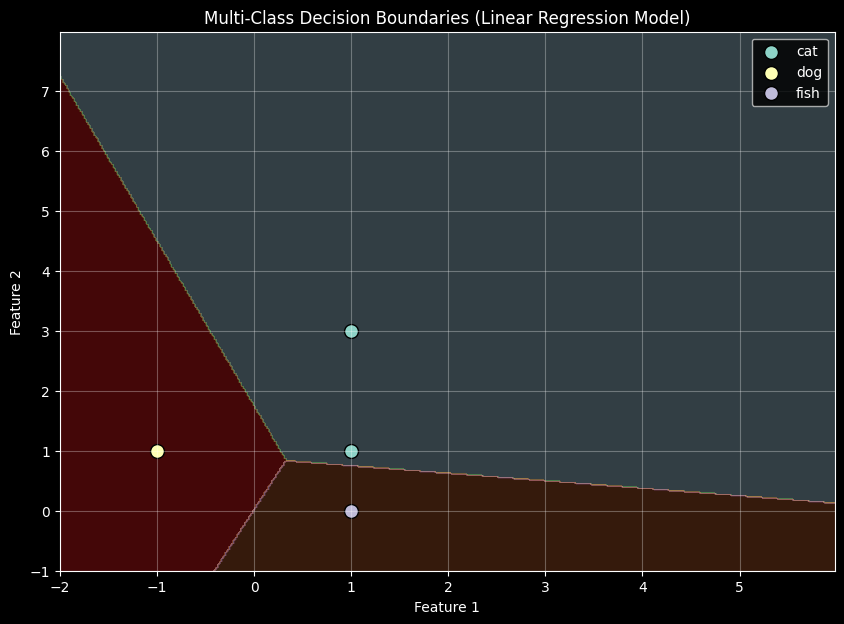

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

# 1. Setup Data
X = np.array([[1,1],[-1,1],[1,3],[1,0]])
y_class = np.array([["cat"],["dog"],["cat"],["fish"]])

# 2. Train Model (Least Squares)
onehot_encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = onehot_encoder.fit_transform(y_class)
X_b = np.c_[np.ones((X.shape[0], 1)), X]
w, _, _, _ = np.linalg.lstsq(X_b, y_train_onehot, rcond=None)

# 3. Create a Grid to cover the feature space
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 5
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 4. Predict for every point in the grid
grid_points = np.c_[np.ones(xx.ravel().shape), xx.ravel(), yy.ravel()]
Z_raw = grid_points @ w
Z = np.argmax(Z_raw, axis=1)
Z = Z.reshape(xx.shape)

# 5. Plotting
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired) # Regions

# Plot original points
for i, label in enumerate(onehot_encoder.categories_[0]):
    indices = np.where(y_class.flatten() == label)
    plt.scatter(X[indices, 0], X[indices, 1], label=label, edgecolors='k', s=100)

plt.title("Multi-Class Decision Boundaries (Linear Regression Model)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

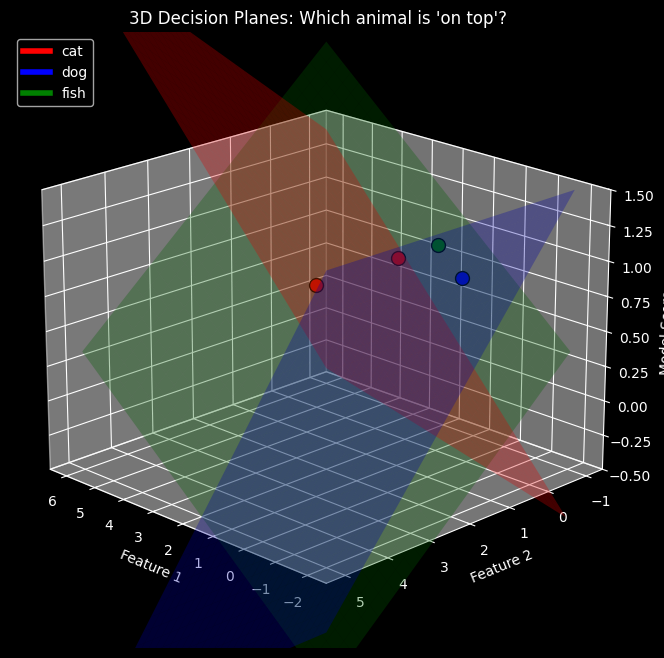

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from mpl_toolkits.mplot3d import Axes3D

# 1. Setup Data
X = np.array([[1, 1], [-1, 1], [1, 3], [1, 0]])
y_class = np.array([["cat"], ["dog"], ["cat"], ["fish"]])

# 2. Train Model
onehot_encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = onehot_encoder.fit_transform(y_class)
class_names = onehot_encoder.categories_[0]

X_b = np.c_[np.ones((X.shape[0], 1)), X]
w, _, _, _ = np.linalg.lstsq(X_b, y_train_onehot, rcond=None)

# 3. Create Grid
x_range = np.linspace(-2, 6, 30)
y_range = np.linspace(-1, 5, 30)
xx, yy = np.meshgrid(x_range, y_range)
grid_coords = np.c_[np.ones(xx.ravel().shape), xx.ravel(), yy.ravel()]

# 4. Calculate heights for each class surface
# Z will have shape (N_points, 3)
Z_raw = grid_coords @ w

# 5. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'blue', 'green'] # Cat, Dog, Fish
alphas = [0.3, 0.3, 0.3]

# Plot each class's decision plane
for i in range(len(class_names)):
    zz = Z_raw[:, i].reshape(xx.shape)
    ax.plot_surface(xx, yy, zz, color=colors[i], alpha=alphas[i], label=class_names[i])

# Plot training points at their "target" height (1 for their class)
for i, label in enumerate(class_names):
    idx = np.where(y_class.flatten() == label)
    # We plot them at height 1.0 because that was the target in one-hot encoding
    ax.scatter(X[idx, 0], X[idx, 1], 1.0, color=colors[i], s=100, edgecolors='k', depthshade=False)

ax.set_title("3D Decision Planes: Which animal is 'on top'?")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Model Score")
ax.set_zlim(-0.5, 1.5)

# Add a manual legend since 3D surface legends are tricky
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=c, lw=4, label=l) for c, l in zip(colors, class_names)]
ax.legend(handles=legend_elements, loc='upper left')

ax.view_init(elev=20, azim=135)
plt.show()

In [61]:
#Demo code 3: Binary classification and polynomial regression
X = np.array([[0,0],[1,1],[1,0],[0,1]])
y = np.array([[-1],[-1],[1],[1]])

#Generate polynomial features
order = 2
poly = PolynomialFeatures(order)
P = poly.fit_transform(X)
print("Matrix P:\n", P)

w = P.T @ inv(P @ P.T) @ y #Least norm solution - Underdetermined system
print("w:\n", w)

#Testing
Xt = np.array([[0.1,0.1],[0.9,0.9],[0.1,0.9],[0.9,0.1]])
Pt = poly.transform(Xt)
print("Matrix Pt:\n", Pt)
yt_raw = Pt @ w
print("yt_raw:\n", yt_raw)
y_pred = np.sign(yt_raw)
print("y_pred:\n", y_pred)

Matrix P:
 [[1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 0. 1. 0. 0.]
 [1. 0. 1. 0. 0. 1.]]
w:
 [[-1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [-4.]
 [ 1.]]
Matrix Pt:
 [[1.   0.1  0.1  0.01 0.01 0.01]
 [1.   0.9  0.9  0.81 0.81 0.81]
 [1.   0.1  0.9  0.01 0.09 0.81]
 [1.   0.9  0.1  0.81 0.09 0.01]]
yt_raw:
 [[-0.82]
 [-0.82]
 [ 0.46]
 [ 0.46]]
y_pred:
 [[-1.]
 [-1.]
 [ 1.]
 [ 1.]]


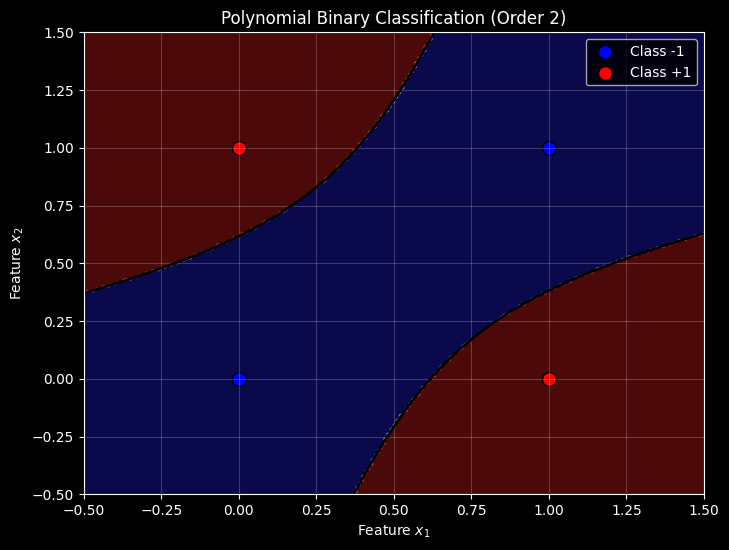

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

# 1. Setup Data
X = np.array([[0,0],[1,1],[1,0],[0,1]])
y = np.array([[-1],[-1],[1],[1]])

# 2. Generate Polynomial Features & Solve (Least Norm)
order = 2
poly = PolynomialFeatures(order)
P = poly.fit_transform(X)
# w = P.T @ inv(P @ P.T) @ y (Your least-norm solution)
w = P.T @ np.linalg.inv(P @ P.T) @ y

# 3. Create a Grid for Visualization
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# 4. Predict over the grid
# Transform the grid points into polynomial features
grid_points = np.c_[xx.ravel(), yy.ravel()]
P_grid = poly.transform(grid_points)
Z_raw = P_grid @ w
Z = np.sign(Z_raw).reshape(xx.shape)

# 5. Plotting
plt.figure(figsize=(8, 6))

# Plot the decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr') # Blue for -1, Red for +1
# Plot the decision boundary line (where raw output is 0)
plt.contour(xx, yy, Z_raw.reshape(xx.shape), levels=[0], colors='black', linewidths=2)

# Plot training points
for i, val in enumerate([-1, 1]):
    idx = np.where(y.flatten() == val)
    color = 'blue' if val == -1 else 'red'
    label = 'Class -1' if val == -1 else 'Class +1'
    plt.scatter(X[idx, 0], X[idx, 1], c=color, label=label, s=100, edgecolors='k')

plt.title(f"Polynomial Binary Classification (Order {order})")
plt.xlabel("Feature $x_1$")
plt.ylabel("Feature $x_2$")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

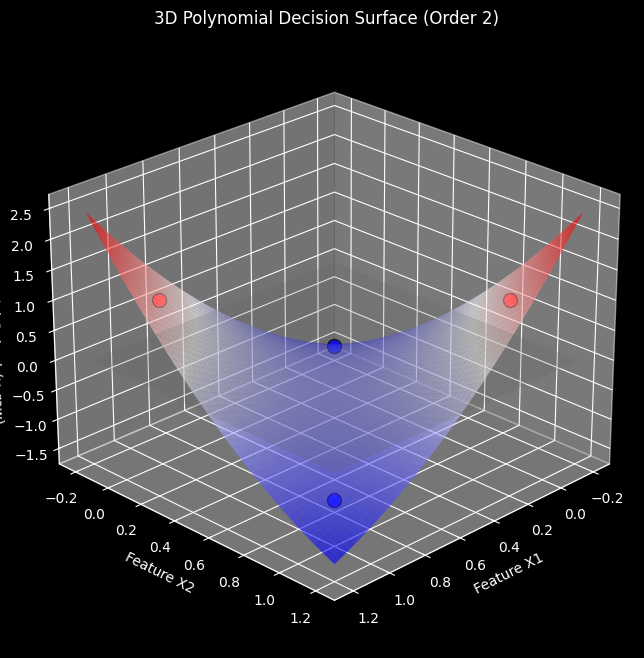

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

# 1. Setup Data
X = np.array([[0,0],[1,1],[1,0],[0,1]])
y = np.array([[-1],[-1],[1],[1]])

# 2. Train Model
order = 2
poly = PolynomialFeatures(order)
P = poly.fit_transform(X)
w = P.T @ np.linalg.inv(P @ P.T) @ y

# 3. Create Grid for 3D
x_range = np.linspace(-0.2, 1.2, 50)
y_range = np.linspace(-0.2, 1.2, 50)
xx, yy = np.meshgrid(x_range, y_range)

# 4. Calculate Z (Raw continuous output)
grid_points = np.c_[xx.ravel(), yy.ravel()]
P_grid = poly.transform(grid_points)
zz_raw = (P_grid @ w).reshape(xx.shape)

# 5. 3D Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the Polynomial Surface
surf = ax.plot_surface(xx, yy, zz_raw, cmap='bwr', alpha=0.6, edgecolor='none')

# Plot the Zero-Plane (The Decision Threshold)
ax.plot_surface(xx, yy, np.zeros_like(zz_raw), color='gray', alpha=0.2)

# Plot Training Points
for i in range(len(y)):
    color = 'blue' if y[i] == -1 else 'red'
    ax.scatter(X[i,0], X[i,1], y[i], color=color, s=100, edgecolors='k', depthshade=False)

ax.set_title(f'3D Polynomial Decision Surface (Order {order})')
ax.set_xlabel('Feature X1')
ax.set_ylabel('Feature X2')
ax.set_zlabel('Raw Model Output (y_raw)')

# Adjust the view for better perspective
ax.view_init(elev=25, azim=45)
plt.show()

In [64]:
#Ridge Regression with L2 Reguralisation

X_train = np.array([[0],[1],[2],[3],[4],[5]])
y_train = np.array([1,2.1,1.8,3.9,4.2,6.1]).reshape(-1,1)

poly = PolynomialFeatures(degree = 5)
P = poly.fit_transform(X_train)

lamda = 1.0
I = np.eye(P.shape[1])

#I[0, 0] = 0 # Usually, we don't regularize the bias term

# Do NOT set I[0,0] = 0 if you want them to match perfectly
#I_primal = np.eye(P.shape[1]) # Size 6x6 (features)
#I_dual = np.eye(P.shape[0])   # Size 6x6 (samples)
#w_ridge_primal = np.linalg.inv(P.T @ P + lamda * I_primal) @ P.T @ y_train
#w_ridge_dual = P.T @ np.linalg.inv(P @ P.T + lamda * I_dual) @ y_train# Updated setup to make them identical

w_ridge_primal = np.linalg.inv(P.T @ P + lamda * I) @ P.T @ y_train #Primal form
w_ridge_dual = P.T @ inv(P @ P.T + lamda * I)@ y_train

print(w_ridge_dual, w_ridge_primal)

w_ridge = w_ridge_dual

w_ols = np.linalg.inv(P.T @ P) @ P.T @ y_train

[[ 0.73180897]
 [ 0.31710254]
 [ 0.19574766]
 [ 0.13807518]
 [-0.06978797]
 [ 0.0080701 ]] [[ 0.73180897]
 [ 0.31710254]
 [ 0.19574766]
 [ 0.13807518]
 [-0.06978797]
 [ 0.0080701 ]]


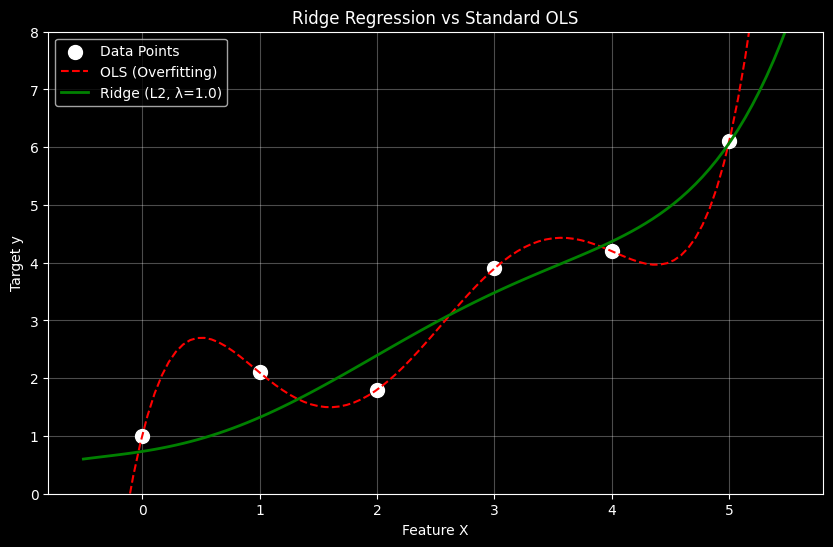

In [65]:
x_plot = np.linspace(-0.5, 5.5, 100).reshape(-1, 1)
P_plot = poly.transform(x_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='white', label='Data Points', s=100)
plt.plot(x_plot, P_plot @ w_ols, 'r--', label='OLS (Overfitting)')
plt.plot(x_plot, P_plot @ w_ridge, 'g-', linewidth=2, label=f'Ridge (L2, λ={lamda})')

plt.ylim(0, 8)
plt.title("Ridge Regression vs Standard OLS")
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

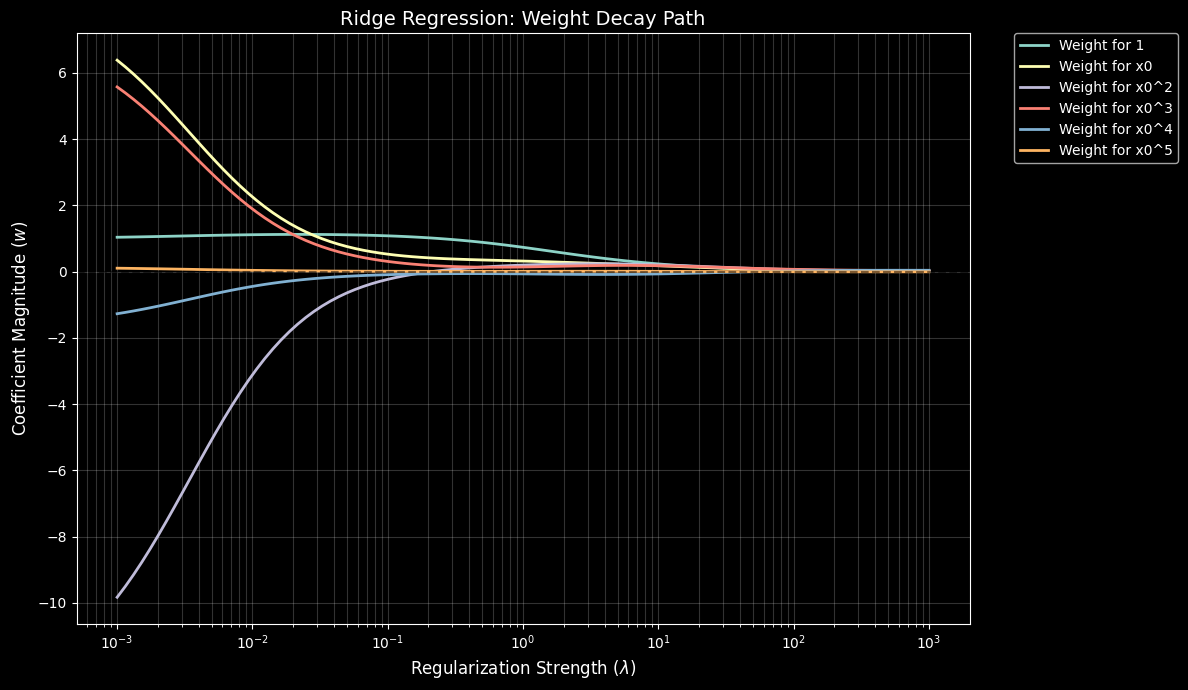

In [66]:
weights = []

# Get the names of the features (e.g., "1", "x", "x^2"...)
feature_names = poly.get_feature_names_out()

for l in lambdas:
    # We use the Primal form here
    # Adding a small identity matrix scaled by lambda
    w = np.linalg.inv(P.T @ P + l * np.eye(P.shape[1])) @ P.T @ y_train
    weights.append(w.flatten())

weights = np.array(weights)

plt.figure(figsize=(12, 7))

# Plot each weight's path specifically
for i in range(weights.shape[1]):
    plt.plot(lambdas, weights[:, i], label=f'Weight for {feature_names[i]}', linewidth=2)

plt.xscale('log')
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Zero line reference
plt.xlabel('Regularization Strength ($\lambda$)', fontsize=12)
plt.ylabel('Coefficient Magnitude ($w$)', fontsize=12)
plt.title('Ridge Regression: Weight Decay Path', fontsize=14)

# Place legend outside so it doesn't cover the lines
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()